<a href="https://colab.research.google.com/github/aruna-31/Deep-Learning-practice-and-basic-projects/blob/main/Implementation_of_InceptionNet_v3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:

import tensorflow as tf
import cv2
import random
import numpy as np
import matplotlib.pyplot as plt
import os
import tensorflow as tf
from tensorflow.keras.applications import *
from tensorflow.keras.models import *
from tensorflow.keras.layers import *
from tensorflow.keras.utils import load_img

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
import pathlib
directory = pathlib.Path("/content/drive/My Drive/Indian_actors_faces")
resultant = "/content/augmentedimages"

# Rotation options
lt = [cv2.ROTATE_180, cv2.ROTATE_90_COUNTERCLOCKWISE, cv2.ROTATE_90_CLOCKWISE]

# Brightness adjustment function
def brightness(img):
    value = random.uniform(0.5, 2)
    hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)
    hsv = np.array(hsv, dtype=np.float64)
    hsv[:,:,1] = hsv[:,:,1] * value
    hsv[:,:,1][hsv[:,:,1] > 255] = 255
    hsv[:,:,2] = hsv[:,:,2] * value
    hsv[:,:,2][hsv[:,:,2] > 255] = 255
    hsv = np.array(hsv, dtype=np.uint8)
    img = cv2.cvtColor(hsv, cv2.COLOR_HSV2BGR)
    return img

In [4]:


classes = []
count = 0
images = []
labels = []
max_images_per_class = 10  # stop after 20 images per actor folder

for actor in os.listdir(directory):
    actor_path = directory / actor

    # skip non-directories
    if not os.path.isdir(actor_path):
        continue

    print(f"Processing {actor}")
    classes.append(actor)
    count += 1
    i1 = 0
    class_images = 0

    for file in os.listdir(actor_path):
        path1 = actor_path / file

        # skip non-image files
        img = cv2.imread(str(path1))
        if img is None:
            continue

        img = cv2.resize(img, (224, 224))
        k = file.split(".")[0]

        cv2.imwrite(f"{resultant}/{k}{i1}.png", img)
        images.append(img)
        labels.append(count)
        i1 += 1
        class_images += 1

        a = random.randint(5, 10)
        while a != 0 and class_images < max_images_per_class:
            img = cv2.rotate(img, lt[random.randint(0, 2)])
            images.append(img)
            cv2.imwrite(f"{resultant}/{k}{i1}.png", img)
            labels.append(count)
            i1 += 1
            class_images += 1

            if a % 2 == 0 and class_images < max_images_per_class:
                img = brightness(img)
                images.append(img)
                cv2.imwrite(f"{resultant}/{k}{i1}.png", img)
                labels.append(count)
                i1 += 1
                class_images += 1

            a -= 1

        # ✅ stop once 20 images are reached for this actor
        if class_images >= max_images_per_class:
            break

images = np.array(images)
labels = np.array(labels)


Processing vinod_khanna
Processing vidya_balan
Processing sridevi
Processing tabu
Processing waheeda_rehman
Processing zarina_wahab
Processing varun_dhawan
Processing zeenat_aman
Processing sunny_deol
Processing soumitra_chatterjee
Processing tinnu_anand
Processing sunil_shetty
Processing utpal_dutt
Processing shreyas_talpade
Processing smita_patil
Processing shashi_kapoor
Processing shah_rukh_khan
Processing sharmila_tagore
Processing sanjay_mishra
Processing saif_ali_khan
Processing sharman_joshi
Processing shabana_azmi
Processing salman_khan
Processing sanjay_dutt
Processing sachin_khedekar
Processing saeed_jaffrey
Processing richa_chadha
Processing riteish_deshmukh
Processing rishi_kapoor
Processing rekha
Processing ratna_pathak_shah
Processing ranvir_shorey
Processing randeep_hooda
Processing ramya_krishnan
Processing ranveer_singh
Processing rani_mukerji
Processing rajinikanth
Processing ranbir_kapoor
Processing rajesh_khanna
Processing rajpal_yadav
Processing rajkummar_rao
Proce

In [5]:
import numpy as np
import os

images.shape


(1350, 224, 224, 3)

In [10]:
from keras.layers import Dense,Dropout, Flatten
from tensorflow.keras.models import *
from tensorflow.keras.applications import InceptionV3

In [11]:
model=InceptionV3(weights="imagenet",include_top=False,input_shape=(224,224,3))
for i in model.layers:
  i.trainable=False

87910968/87910968 ━━━━━━━━━━━━━━━━━━━━ 5s 0us/step


In [12]:
len(model.layers)

311

In [13]:
model.summary()

Model: "inception_v3"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 111, 111,  │        864 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 111, 111,  │         96 │ conv2d[0][0]      │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation          │ (None, 111, 111,  │          0 │ batch_normalizat… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 109, 109,  │      9,216 │ activation[0][0]  │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 109, 109,  │         96 │ conv2d_1[0][0]    │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_1        │ (None, 109, 109,  │          0 │ batch_normalizat… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 109, 109,  │     18,432 │ activation_1[0][… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 109, 109,  │        192 │ conv2d_2[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_2        │ (None, 109, 109,  │          0 │ batch_normalizat… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 54, 54,    │          0 │ activation_2[0][… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 54, 54,    │      5,120 │ max_pooling2d[0]… │
│                     │ 80)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 54, 54,    │        240 │ conv2d_3[0][0]    │
│ (BatchNormalizatio… │ 80)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_3        │ (None, 54, 54,    │          0 │ batch_normalizat… │
│ (Activation)        │ 80)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 52, 52,    │    138,240 │ activation_3[0][… │
│                     │ 192)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 52, 52,    │        576 │ conv2d_4[0][0]    │
│ (BatchNormalizatio… │ 192)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_4        │ (None, 52, 52,    │          0 │ batch_normalizat

 Total params: 21,802,784 (83.17 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 21,802,784 (83.17 MB)

In [15]:
from tensorflow.keras.layers import AveragePooling2D, Dropout, Flatten, Dense, GlobalAveragePooling2D
transfer_inception_v3=Sequential()
#adding pretrained model
transfer_inception_v3.add(model)
#adding customer layers
transfer_inception_v3.add(GlobalAveragePooling2D())
transfer_inception_v3.add(Dense(512,activation="relu"))
transfer_inception_v3.add(Dense(128,activation="relu"))
transfer_inception_v3.add(Dense(15,activation="softmax"))

In [18]:
len(transfer_inception_v3.layers)

5

In [22]:
transfer_inception_v3.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ inception_v3 (Functional)       │ (None, 5, 5, 2048)     │    21,802,784 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │     1,049,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        65,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 15)             │         1,935 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 22,919,471 (87.43 MB)

 Trainable params: 1,116,687 (4.26 MB)

 Non-trainable params: 21,802,784 (83.17 MB)

In [20]:
import tensorflow as tf
class myCallback(tf.keras.callbacks.Callback):
  def on_epoch_end(self,epoch,logs={}):
    print("call")
    if(logs.get('accuracy')>.99):
      print("\nReached %2.2f%% accuracy, so stopping training"%(99))
      self.model.stop_training=True
callbacks=myCallback()

In [24]:

labels_zero_indexed = labels - 1
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
new_model = Sequential()
new_model.add(model)
new_model.add(GlobalAveragePooling2D())
new_model.add(Dense(512, activation="relu"))
new_model.add(Dense(128, activation="relu"))
new_model.add(Dense(len(classes), activation="softmax"))
transfer_inception_v3 = new_model
transfer_inception_v3.compile(optimizer="adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"])
transfer_inception_v3.fit(images, labels_zero_indexed, epochs=10, callbacks=[callbacks])

Epoch 1/10
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 241ms/step - accuracy: 0.0039 - loss: 15.7454call
43/43 ━━━━━━━━━━━━━━━━━━━━ 29s 241ms/step - accuracy: 0.0044 - loss: 8.8478
Epoch 2/10
42/43 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step - accuracy: 0.0084 - loss: 4.9068call
43/43 ━━━━━━━━━━━━━━━━━━━━ 3s 65ms/step - accuracy: 0.0074 - loss: 4.9069
Epoch 3/10
42/43 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step - accuracy: 0.0063 - loss: 4.9083call
43/43 ━━━━━━━━━━━━━━━━━━━━ 3s 67ms/step - accuracy: 0.0044 - loss: 4.9052
Epoch 4/10
42/43 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step - accuracy: 0.0067 - loss: 4.9043call
43/43 ━━━━━━━━━━━━━━━━━━━━ 3s 66ms/step - accuracy: 0.0059 - loss: 4.8989
Epoch 5/10
42/43 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step - accuracy: 0.0032 - loss: 4.9054call
43/43 ━━━━━━━━━━━━━━━━━━━━ 3s 63ms/step - accuracy: 0.0044 - loss: 4.9059
Epoch 6/10
42/43 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step - accuracy: 0.0090 - loss: 4.9055call
43/43 ━━━━━━━━━━━━━━━━━━━━ 3s 63ms/step - accuracy: 0.0081 - loss: 4.9059
Epoch 7/10
42/43 ━

In [26]:
transfer_inception_v3.evaluate(images,labels_zero_indexed)

43/43 ━━━━━━━━━━━━━━━━━━━━ 14s 156ms/step - accuracy: 0.0074 - loss: 4.9053


[4.90529203414917, 0.007407407276332378]

In [30]:
def predict(i,transferVGG,labels):
  path1=f"{directory}/{i}"
  img=cv2.imread(path1)
  img=cv2.resize(img,(224,224))
  a=np.argmax(transferVGG.predict(np.array([img])))
  img=cv2.putText(img,labels[a],(25,25),cv2.FONT_HERSHEY_SIMPLEX,1,(225,225,0),3,cv2.LINE_AA)
  plt.imshow(img)

1/1 ━━━━━━━━━━━━━━━━━━━━ 9s 9s/step


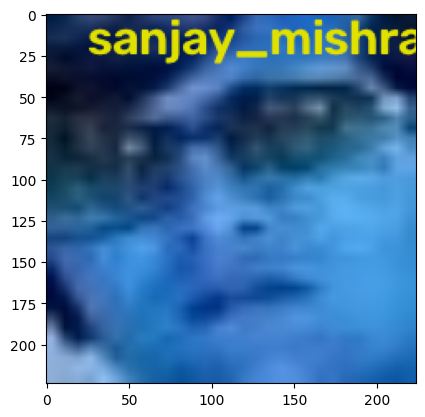

In [31]:
predict("vinod_khanna/0b035338f4.jpg",transfer_inception_v3,classes)